In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

fake = pd.read_csv("Fake.csv")
true = pd.read_csv("True.csv")

print("Fake shape:", fake.shape)
print("True shape:", true.shape)

fake.head()

Fake shape: (23481, 4)
True shape: (21417, 4)


,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [2]:
fake["label"] = 0   # Fake news
true["label"] = 1   # True news

df = pd.concat([fake, true], axis=0)

df.head()

,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0


In [3]:
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

df.head()

,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    44898 non-null  object
 1   text     44898 non-null  object
 2   subject  44898 non-null  object
 3   date     44898 non-null  object
 4   label    44898 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 1.7+ MB


In [5]:
df.isnull().sum()

title      0
text       0
subject    0
date       0
label      0
dtype: int64

In [6]:
df.duplicated().sum()

209

In [7]:
df["label"].value_counts()

label
0    23481
1    21417
Name: count, dtype: int64

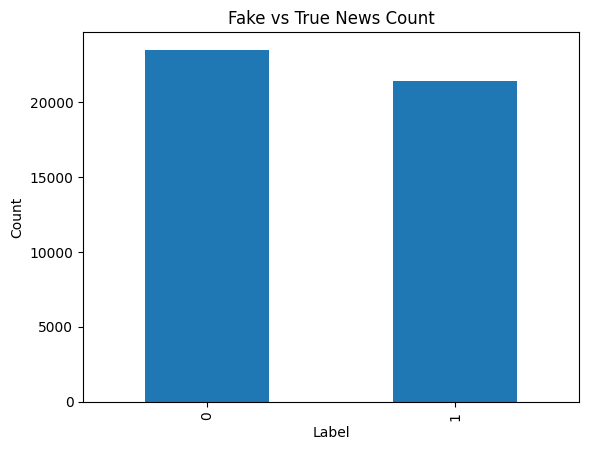

In [8]:
df["label"].value_counts().plot(kind="bar")
plt.title("Fake vs True News Count")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

In [9]:
df = df.drop_duplicates()

In [10]:
df.duplicated().sum()

0

In [13]:
%pip install nltk

import re
import string
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.6 MB ? eta -:--:--
   -------------------- ------------------- 0.8/1.6 MB 2.4 MB/s eta 0:00:01
   --------------------------------- ------ 1.3/1.6 MB 2.9 MB/s eta 0:00:01
   ---------------------------------------- 1.6/1.6 MB 2.2 MB/s eta 0:00:00

   ---------------------------------------- 0/4 [tqdm]
   ---------------------------------------- 0/4 [tqdm]
   ---------- ----------------------------- 1/4 [regex]
   -------------------- ------------------- 2/4 [click]
   -------------------- ------------------- 2/4 [click]
   -------------------- ------------------- 2/4 [click]
   -------------------- ------------------- 2/4 [click]
   -------------------- ------------------- 2/4 [click]
   ------------------------------ --------- 3/4 [nltk]
   ------------------------------ --------- 3/4 [nltk]
   ------------------------------ --------- 3/4 [nltk]
   -------------------

In [14]:
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Huawei\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Huawei\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [15]:
lemmatizer = WordNetLemmatizer()

stop_words = set(stopwords.words('english'))

In [16]:
def clean_text(text):

    # lowercase
    text = text.lower()

    # remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', text)

    # remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # remove numbers
    text = re.sub(r'\d+', '', text)

    # tokenize
    words = text.split()

    # remove stopwords + lemmatization
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

In [17]:
df["clean_text"] = df["text"].apply(clean_text)

In [18]:
df[["text", "clean_text"]].head()

,text,clean_text
0,"21st Century Wire says Ben Stein, reputable pr...",st century wire say ben stein reputable profes...
1,WASHINGTON (Reuters) - U.S. President Donald T...,washington reuters u president donald trump re...
2,(Reuters) - Puerto Rico Governor Ricardo Rosse...,reuters puerto rico governor ricardo rossello ...
3,"On Monday, Donald Trump once again embarrassed...",monday donald trump embarrassed country accide...
4,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",glasgow scotland reuters u presidential candid...


In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

In [21]:
X = df["clean_text"]

y = df["label"]

In [22]:
vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(X)

In [23]:
print(X.shape)

(44689, 5000)


In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [25]:
print(X_train.shape)
print(X_test.shape)

(35751, 5000)
(8938, 5000)


# Logistic Regression


---






In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [27]:
lr_model = LogisticRegression()

In [28]:
lr_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [29]:
y_pred = lr_model.predict(X_test)

In [30]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9883642873125978


In [31]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4652
           1       0.98      0.99      0.99      4286

    accuracy                           0.99      8938
   macro avg       0.99      0.99      0.99      8938
weighted avg       0.99      0.99      0.99      8938



In [32]:
print(confusion_matrix(y_test, y_pred))

[[4585   67]
 [  37 4249]]


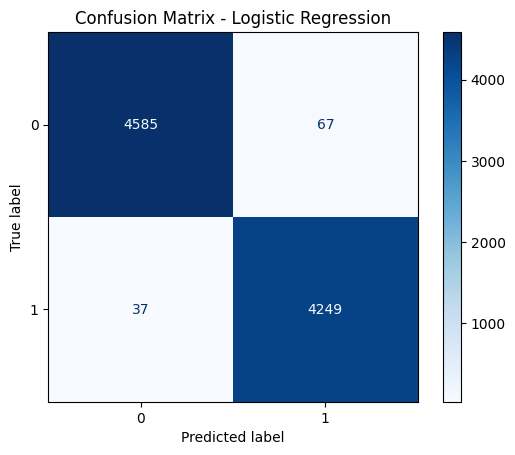

In [61]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predict on test data
y_pred = lr_model.predict(X_test)

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

# Naive Bayes



---





In [33]:
from sklearn.naive_bayes import MultinomialNB

In [34]:
nb_model = MultinomialNB()

In [35]:

nb_model.fit(X_train, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [36]:
y_pred_nb = nb_model.predict(X_test)

In [37]:
nb_accuracy = accuracy_score(y_test, y_pred_nb)

print("Naive Bayes Accuracy:", nb_accuracy)

Naive Bayes Accuracy: 0.9455135377041843


In [38]:
print(classification_report(y_test, y_pred_nb))

              precision    recall  f1-score   support

           0       0.95      0.94      0.95      4652
           1       0.94      0.95      0.94      4286

    accuracy                           0.95      8938
   macro avg       0.95      0.95      0.95      8938
weighted avg       0.95      0.95      0.95      8938



In [39]:
print(confusion_matrix(y_test, y_pred_nb))

[[4380  272]
 [ 215 4071]]


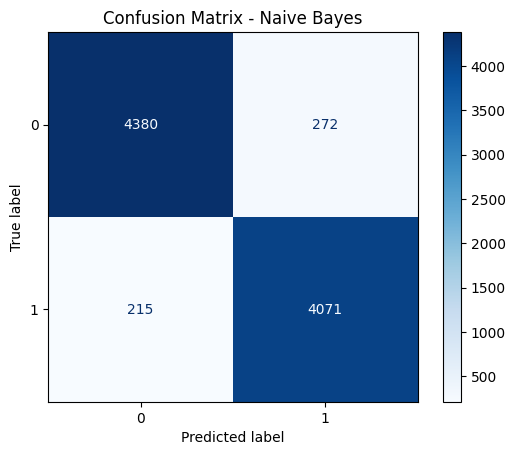

In [64]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predict on test data
y_pred = nb_model.predict(X_test)

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')

plt.title("Confusion Matrix - Naive Bayes")
plt.show()

## SVM

---



In [40]:
from sklearn.svm import LinearSVC

In [41]:
svm_model = LinearSVC()

In [42]:
svm_model.fit(X_train, y_train)

,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,verbose,0
,random_state,None


In [43]:
y_pred_svm = svm_model.predict(X_test)

In [44]:
svm_accuracy = accuracy_score(y_test, y_pred_svm)

print("SVM Accuracy:", svm_accuracy)

SVM Accuracy: 0.9950771984784068


In [45]:
print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00      4652
           1       0.99      1.00      0.99      4286

    accuracy                           1.00      8938
   macro avg       1.00      1.00      1.00      8938
weighted avg       1.00      1.00      1.00      8938



In [46]:
print(confusion_matrix(y_test, y_pred_svm))

[[4623   29]
 [  15 4271]]


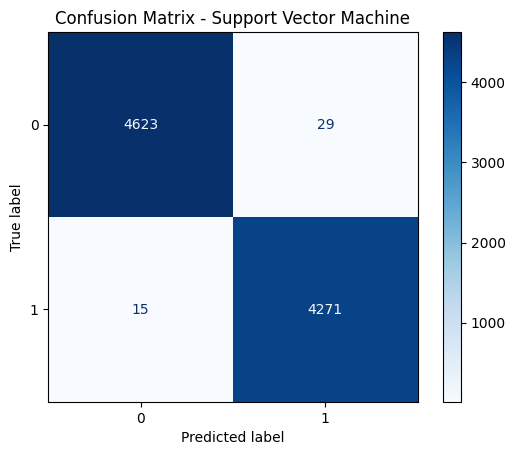

In [66]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predict on test data
y_pred = svm_model.predict(X_test)

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')

plt.title("Confusion Matrix - Support Vector Machine")
plt.show()

# Random Forest


---







In [47]:
from sklearn.ensemble import RandomForestClassifier

In [48]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

In [49]:
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [50]:
y_pred_rf = rf_model.predict(X_test)

In [51]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.9976504810919669


In [52]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4652
           1       1.00      1.00      1.00      4286

    accuracy                           1.00      8938
   macro avg       1.00      1.00      1.00      8938
weighted avg       1.00      1.00      1.00      8938



In [53]:
print(confusion_matrix(y_test, y_pred_rf))

[[4636   16]
 [   5 4281]]


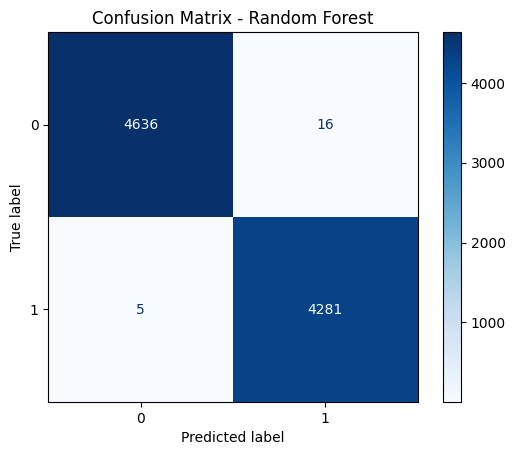

In [68]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predict on test data
y_pred = rf_model.predict(X_test)

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')

plt.title("Confusion Matrix - Random Forest")
plt.show()

In [54]:
c_values = [0.1, 1, 10, 100]

accuracies = []

# **Results Table**:

In [55]:
results = {
    "Model": [
        "Logistic Regression",
        "Naive Bayes",
        "SVM",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy,
        nb_accuracy,
        svm_accuracy,
        rf_accuracy
    ]
}

In [56]:
results_df = pd.DataFrame(results)

results_df

,Model,Accuracy
0,Logistic Regression,0.988364
1,Naive Bayes,0.945514
2,SVM,0.995077
3,Random Forest,0.997650


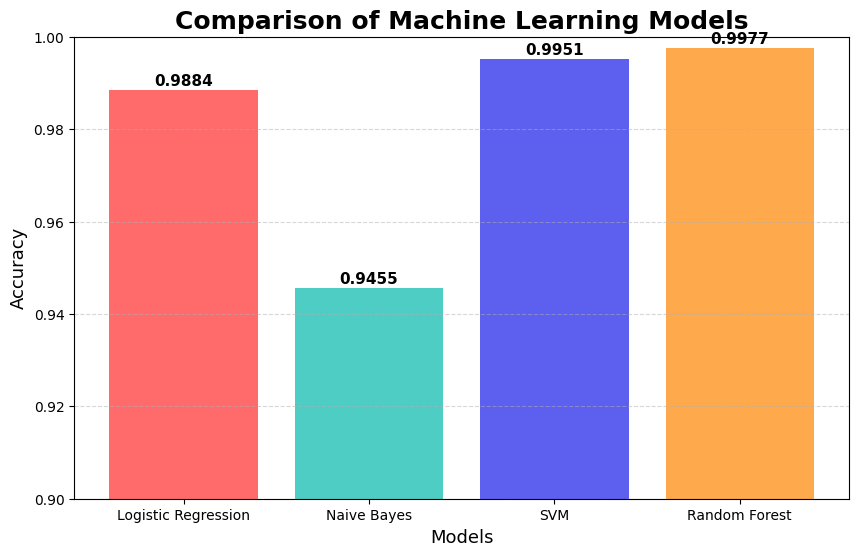

In [70]:
plt.figure(figsize=(10,6))

colors = ['#FF6B6B', '#4ECDC4', '#5D5FEF', '#FFA94D']

bars = plt.bar(
    results_df["Model"],
    results_df["Accuracy"],
    color=colors
)

plt.title(
    "Comparison of Machine Learning Models",
    fontsize=18,
    fontweight='bold'
)

plt.xlabel(
    "Models",
    fontsize=13
)

plt.ylabel(
    "Accuracy",
    fontsize=13
)

plt.ylim(0.90, 1.00)

plt.grid(axis='y', linestyle='--', alpha=0.5)

# Add values on top
for bar in bars:
    yval = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval + 0.001,
        f"{yval:.4f}",
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

plt.show()

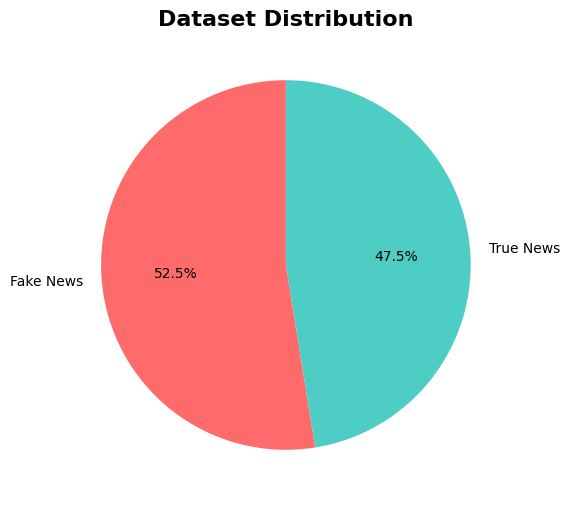

In [69]:
counts = df["label"].value_counts()

labels = ["Fake News", "True News"]

colors = ['#FF6B6B', '#4ECDC4']

plt.figure(figsize=(6,6))

plt.pie(
    counts,
    labels=labels,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90
)

plt.title(
    "Dataset Distribution",
    fontsize=16,
    fontweight='bold'
)

plt.show()

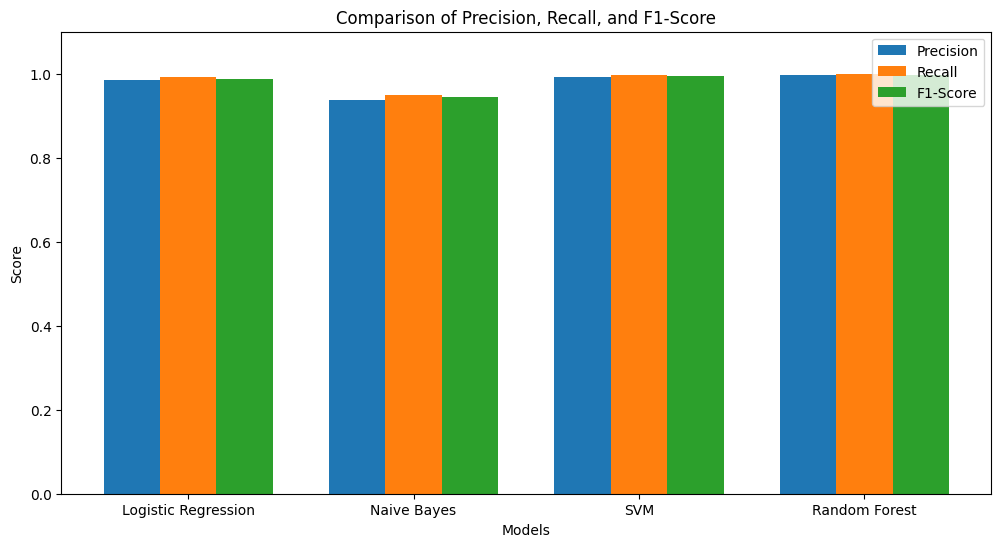

In [78]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

# Predictions for Each Model
y_pred_lr = lr_model.predict(X_test)
y_pred_nb = nb_model.predict(X_test)
y_pred_svm = svm_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)

# Calculate Metrics
precision = [
    precision_score(y_test, y_pred_lr),
    precision_score(y_test, y_pred_nb),
    precision_score(y_test, y_pred_svm),
    precision_score(y_test, y_pred_rf)
]

recall = [
    recall_score(y_test, y_pred_lr),
    recall_score(y_test, y_pred_nb),
    recall_score(y_test, y_pred_svm),
    recall_score(y_test, y_pred_rf)
]

f1 = [
    f1_score(y_test, y_pred_lr),
    f1_score(y_test, y_pred_nb),
    f1_score(y_test, y_pred_svm),
    f1_score(y_test, y_pred_rf)
]

# Model Names
models = ['Logistic Regression', 'Naive Bayes', 'SVM', 'Random Forest']

# Create Comparison Graph
x = np.arange(len(models))
width = 0.25

plt.figure(figsize=(12,6))

plt.bar(x - width, precision, width, label='Precision')
plt.bar(x, recall, width, label='Recall')
plt.bar(x + width, f1, width, label='F1-Score')

plt.xlabel('Models')
plt.ylabel('Score')
plt.title('Comparison of Precision, Recall, and F1-Score')
plt.xticks(x, models)

plt.ylim(0,1.1)

plt.legend()

plt.show()

In [79]:
%pip install wordcloud
from wordcloud import WordCloud

Note: you may need to restart the kernel to use updated packages.


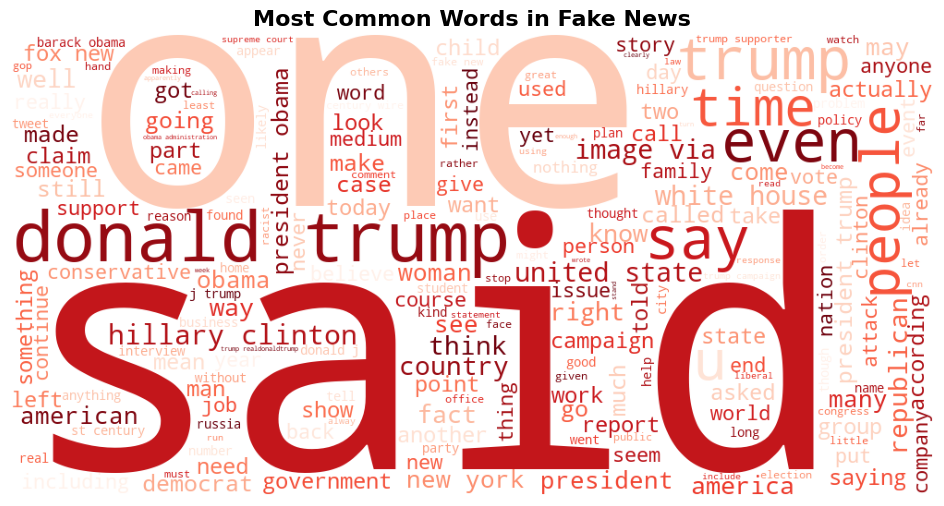

In [80]:
fake_words = " ".join(
    df[df["label"] == 0]["clean_text"]
)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    colormap='Reds'
).generate(fake_words)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud)

plt.axis("off")

plt.title(
    "Most Common Words in Fake News",
    fontsize=16,
    fontweight='bold'
)

plt.show()

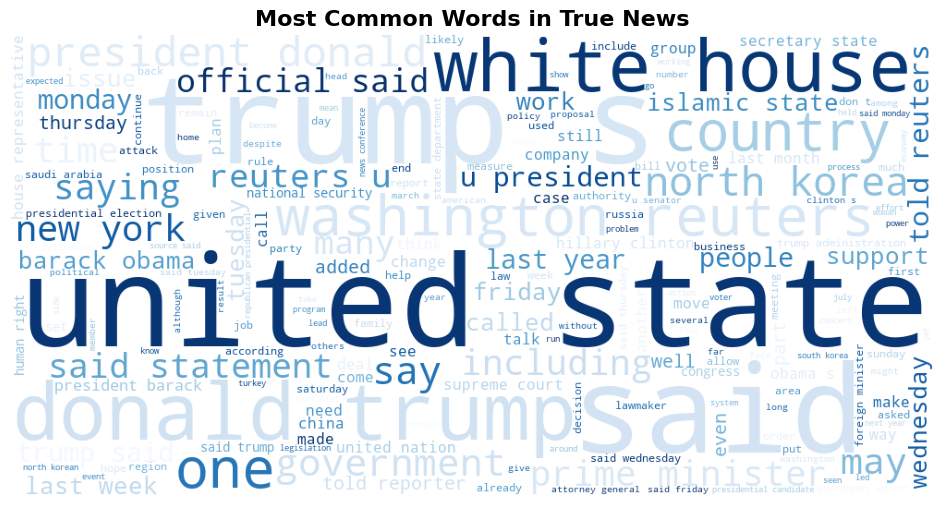

In [81]:
true_words = " ".join(
    df[df["label"] == 1]["clean_text"]
)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    colormap='Blues'
).generate(true_words)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud)

plt.axis("off")

plt.title(
    "Most Common Words in True News",
    fontsize=16,
    fontweight='bold'
)

plt.show()

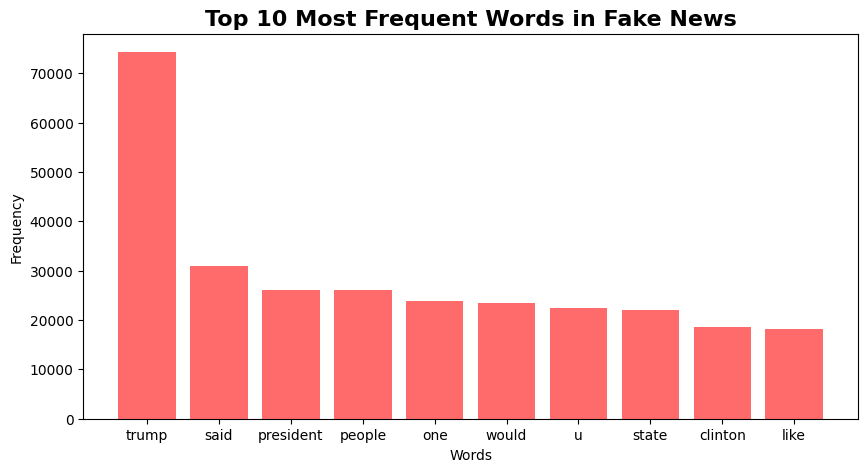

In [82]:
from collections import Counter

fake_text = " ".join(
    df[df["label"] == 0]["clean_text"]
)

words = fake_text.split()

common_words = Counter(words).most_common(10)

words_df = pd.DataFrame(
    common_words,
    columns=["Word", "Frequency"]
)

plt.figure(figsize=(10,5))

plt.bar(
    words_df["Word"],
    words_df["Frequency"],
    color='#FF6B6B'
)

plt.title(
    "Top 10 Most Frequent Words in Fake News",
    fontsize=16,
    fontweight='bold'
)

plt.xlabel("Words")
plt.ylabel("Frequency")

plt.show()

# Random Forest Hyperparameter Tuning

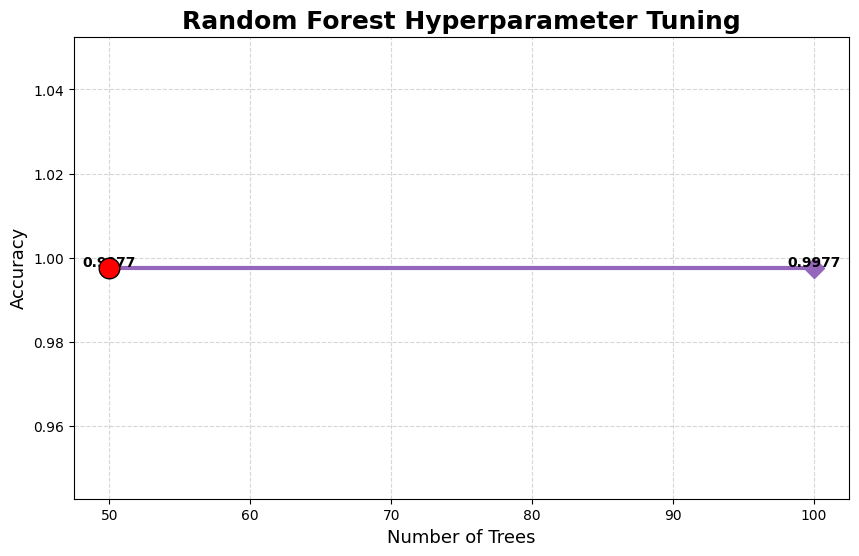

In [83]:
# Random Forest Hyperparameter Tuning

rf_trees = [50, 100]

rf_acc = []

for n in rf_trees:

    model = RandomForestClassifier(
        n_estimators=n,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    rf_acc.append(acc)


# Plot

plt.figure(figsize=(10,6))

plt.plot(
    rf_trees,
    rf_acc,
    marker='D',
    markersize=10,
    linewidth=3,
    color='#9467bd'
)

plt.title(
    "Random Forest Hyperparameter Tuning",
    fontsize=18,
    fontweight='bold'
)

plt.xlabel(
    "Number of Trees",
    fontsize=13
)

plt.ylabel(
    "Accuracy",
    fontsize=13
)

plt.grid(
    True,
    linestyle='--',
    alpha=0.5
)

# Add accuracy values

for x, y in zip(rf_trees, rf_acc):

    plt.text(
        x,
        y + 0.0003,
        f"{y:.4f}",
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

# Highlight best value

best_index = rf_acc.index(max(rf_acc))

best_x = rf_trees[best_index]
best_y = rf_acc[best_index]

plt.scatter(
    best_x,
    best_y,
    s=220,
    color='red',
    edgecolor='black',
    zorder=5
)

plt.show()

# SVM Hyperparameter Tuning

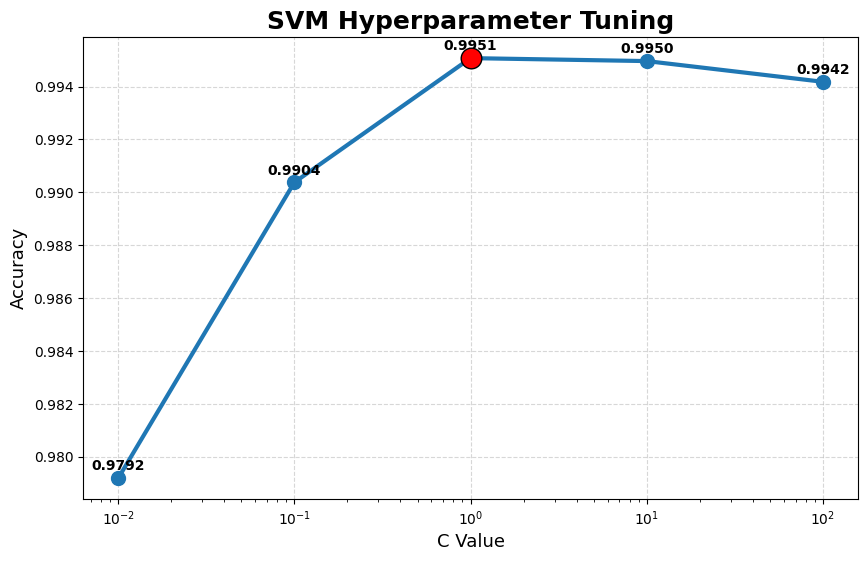

In [84]:
# SVM Hyperparameter Tuning

svm_c_values = [0.01, 0.1, 1, 10, 100]

svm_acc = []

for c in svm_c_values:

    model = LinearSVC(
        C=c,
        max_iter=10000
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    svm_acc.append(acc)


# Plot

plt.figure(figsize=(10,6))

plt.plot(
    svm_c_values,
    svm_acc,
    marker='o',
    markersize=10,
    linewidth=3,
    color='#1f77b4'
)

plt.xscale('log')

plt.title(
    "SVM Hyperparameter Tuning",
    fontsize=18,
    fontweight='bold'
)

plt.xlabel(
    "C Value",
    fontsize=13
)

plt.ylabel(
    "Accuracy",
    fontsize=13
)

plt.grid(
    True,
    linestyle='--',
    alpha=0.5
)

# Add accuracy values

for x, y in zip(svm_c_values, svm_acc):

    plt.text(
        x,
        y + 0.0003,
        f"{y:.4f}",
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

# Highlight best value

best_index = svm_acc.index(max(svm_acc))

best_x = svm_c_values[best_index]
best_y = svm_acc[best_index]

plt.scatter(
    best_x,
    best_y,
    s=220,
    color='red',
    edgecolor='black',
    zorder=5
)

plt.show()

# Logistic Regression Hyperparameter Tuning

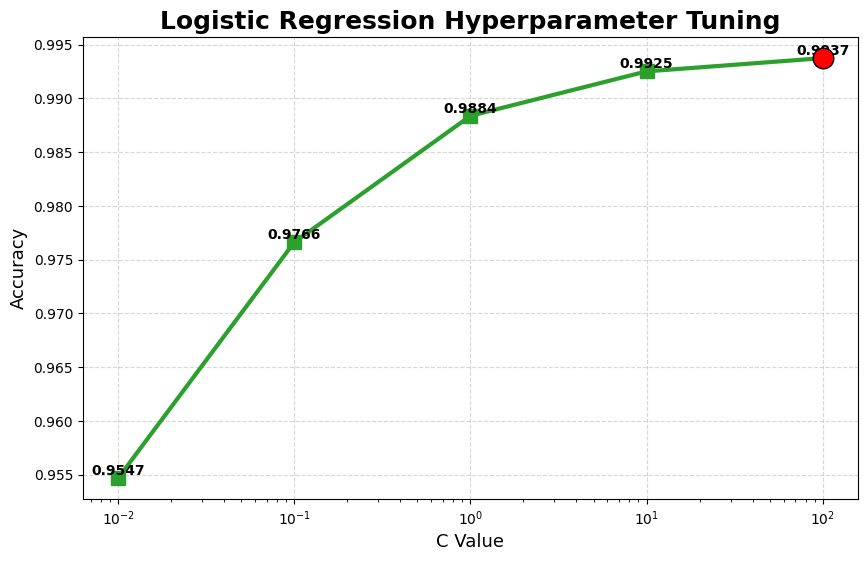

In [85]:
# Logistic Regression Hyperparameter Tuning

lr_c_values = [0.01, 0.1, 1, 10, 100]

lr_acc = []

for c in lr_c_values:

    model = LogisticRegression(
        C=c,
        max_iter=5000
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    lr_acc.append(acc)


# Plot

plt.figure(figsize=(10,6))

plt.plot(
    lr_c_values,
    lr_acc,
    marker='s',
    markersize=10,
    linewidth=3,
    color='#2ca02c'
)

plt.xscale('log')

plt.title(
    "Logistic Regression Hyperparameter Tuning",
    fontsize=18,
    fontweight='bold'
)

plt.xlabel(
    "C Value",
    fontsize=13
)

plt.ylabel(
    "Accuracy",
    fontsize=13
)

plt.grid(
    True,
    linestyle='--',
    alpha=0.5
)

# Add accuracy values

for x, y in zip(lr_c_values, lr_acc):

    plt.text(
        x,
        y + 0.0003,
        f"{y:.4f}",
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

# Highlight best value

best_index = lr_acc.index(max(lr_acc))

best_x = lr_c_values[best_index]
best_y = lr_acc[best_index]

plt.scatter(
    best_x,
    best_y,
    s=220,
    color='red',
    edgecolor='black',
    zorder=5
)

plt.show()

# Naive Bayes Hyperparameter Tuning

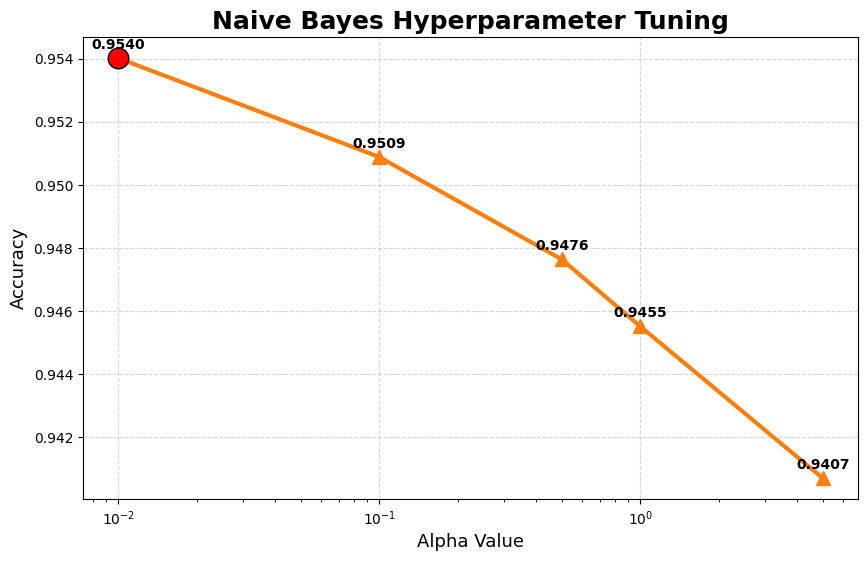

In [86]:
# Naive Bayes Hyperparameter Tuning

nb_alpha_values = [0.01, 0.1, 0.5, 1, 5]

nb_acc = []

for alpha in nb_alpha_values:

    model = MultinomialNB(alpha=alpha)

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    nb_acc.append(acc)


# Plot

plt.figure(figsize=(10,6))

plt.plot(
    nb_alpha_values,
    nb_acc,
    marker='^',
    markersize=10,
    linewidth=3,
    color='#ff7f0e'
)

plt.xscale('log')

plt.title(
    "Naive Bayes Hyperparameter Tuning",
    fontsize=18,
    fontweight='bold'
)

plt.xlabel(
    "Alpha Value",
    fontsize=13
)

plt.ylabel(
    "Accuracy",
    fontsize=13
)

plt.grid(
    True,
    linestyle='--',
    alpha=0.5
)

# Add accuracy values

for x, y in zip(nb_alpha_values, nb_acc):

    plt.text(
        x,
        y + 0.0003,
        f"{y:.4f}",
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

# Highlight best value

best_index = nb_acc.index(max(nb_acc))

best_x = nb_alpha_values[best_index]
best_y = nb_acc[best_index]

plt.scatter(
    best_x,
    best_y,
    s=220,
    color='red',
    edgecolor='black',
    zorder=5
)

plt.show()

ROC Curve & AUC Score
1. ROC Curve shows:
- how good the model is at distinguishing between classes.

2. AUC Score:
- closer to 1.0 → excellent model
- around 0.5 → bad/random model

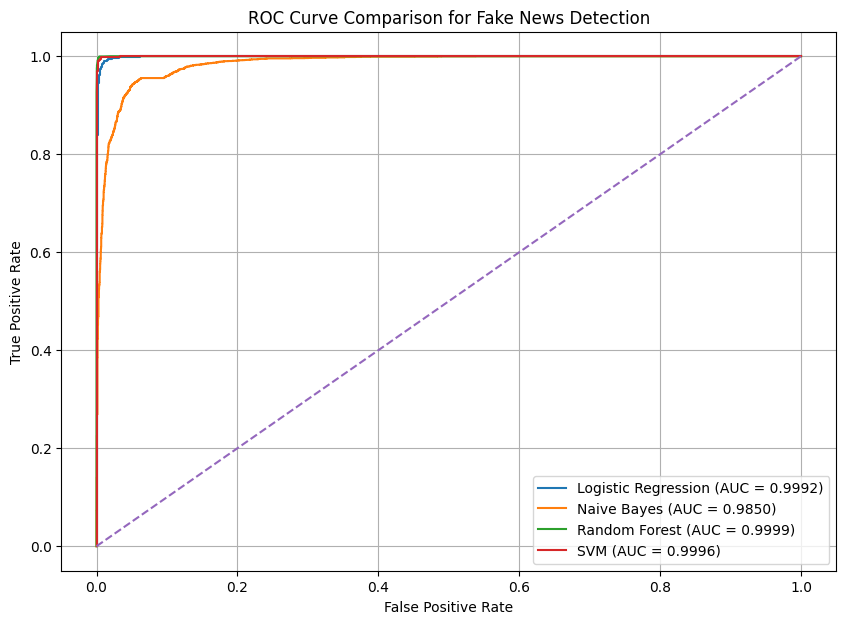

AUC Scores:
Logistic Regression AUC: 0.9992
Naive Bayes AUC: 0.9850
Random Forest AUC: 0.9999
SVM AUC: 0.9996


In [89]:
# ROC Curve & AUC Score Comparison
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt


lr_probs = lr_model.predict_proba(X_test)[:, 1]
nb_probs = nb_model.predict_proba(X_test)[:, 1]
rf_probs = rf_model.predict_proba(X_test)[:, 1]
svm_scores = svm_model.decision_function(X_test)

lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)
nb_fpr, nb_tpr, _ = roc_curve(y_test, nb_probs)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)
svm_fpr, svm_tpr, _ = roc_curve(y_test, svm_scores)

lr_auc = auc(lr_fpr, lr_tpr)
nb_auc = auc(nb_fpr, nb_tpr)
rf_auc = auc(rf_fpr, rf_tpr)
svm_auc = auc(svm_fpr, svm_tpr)

# Plot ROC Curves
plt.figure(figsize=(10, 7))

plt.plot(lr_fpr, lr_tpr,
         label=f'Logistic Regression (AUC = {lr_auc:.4f})')

plt.plot(nb_fpr, nb_tpr,
         label=f'Naive Bayes (AUC = {nb_auc:.4f})')

plt.plot(rf_fpr, rf_tpr,
         label=f'Random Forest (AUC = {rf_auc:.4f})')

plt.plot(svm_fpr, svm_tpr,
         label=f'SVM (AUC = {svm_auc:.4f})')

# Random guessing line
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison for Fake News Detection')

plt.legend(loc='lower right')

plt.grid(True)

plt.show()


print("AUC Scores:")
print(f"Logistic Regression AUC: {lr_auc:.4f}")
print(f"Naive Bayes AUC: {nb_auc:.4f}")
print(f"Random Forest AUC: {rf_auc:.4f}")
print(f"SVM AUC: {svm_auc:.4f}")

Missing Cross Validation


In [90]:
# Cross Validation for All Models
from sklearn.model_selection import cross_val_score
import numpy as np
import pandas as pd


# Logistic Regression
lr_cv_scores = cross_val_score(
    lr_model,
    X_train,
    y_train,
    cv=5,
    scoring='accuracy'
)

# Naive Bayes
nb_cv_scores = cross_val_score(
    nb_model,
    X_train,
    y_train,
    cv=5,
    scoring='accuracy'
)

# Random Forest
rf_cv_scores = cross_val_score(
    rf_model,
    X_train,
    y_train,
    cv=5,
    scoring='accuracy'
)

# SVM
svm_cv_scores = cross_val_score(
    svm_model,
    X_train,
    y_train,
    cv=5,
    scoring='accuracy'
)


print("Logistic Regression CV Scores:", lr_cv_scores)
print("Naive Bayes CV Scores:", nb_cv_scores)
print("Random Forest CV Scores:", rf_cv_scores)
print("SVM CV Scores:", svm_cv_scores)

print("\nAverage Cross Validation Accuracy:\n")

print(f"Logistic Regression Mean Accuracy: {np.mean(lr_cv_scores):.4f}")
print(f"Naive Bayes Mean Accuracy: {np.mean(nb_cv_scores):.4f}")
print(f"Random Forest Mean Accuracy: {np.mean(rf_cv_scores):.4f}")
print(f"SVM Mean Accuracy: {np.mean(svm_cv_scores):.4f}")

cv_results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Naive Bayes',
        'Random Forest',
        'SVM'
    ],
    
    'Mean CV Accuracy': [
        np.mean(lr_cv_scores),
        np.mean(nb_cv_scores),
        np.mean(rf_cv_scores),
        np.mean(svm_cv_scores)
    ]
})


print("\nCross Validation Results Table:\n")
print(cv_results)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    cv_results['Model'],
    cv_results['Mean CV Accuracy']
)

plt.xlabel('Models')
plt.ylabel('Mean Cross Validation Accuracy')
plt.title('Cross Validation Accuracy Comparison')

plt.ylim(0.9, 1.0)

plt.show()

InvalidParameterError: The 'y' parameter of cross_val_score must be an array-like or None. Got 0.9407026180353547 instead.

# **The results show that all models performed well in detecting fake and real news. Random Forest achieved the highest accuracy of 99.75%, followed by SVM with 99.51%, Logistic Regression with 98.84%, and Naive Bayes with 94.55%. Based on the accuracy, precision, recall, F1-score, and confusion matrix, Random Forest was selected as the best-performing model for this dataset.**